### Implement the Model - XGBoost

### 1. Import the python libraries

In [18]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline 
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
import joblib
import gc
from sklearn.base import BaseEstimator, ClassifierMixin
import seaborn as sns

### 2. Import the data 

In [6]:
train_filepath = '../data/processed/neiss_feature-engineered_train_data.parquet'
eval_filepath = '../data/processed/neiss_feature-engineered_eval_data.parquet'
holdout_filepath =  '../data/processed/neiss_feature-engineered_holdout_data.parquet'

In [7]:
train_data= pd.read_parquet(train_filepath)
eval_data = pd.read_parquet(eval_filepath)
holdout_data = pd.read_parquet(holdout_filepath)

### 3. Setup the train/evaluation dataset

In [8]:
X_train = train_data.drop(columns=['Hospitalized'])
y_train = train_data['Hospitalized']
X_eval = eval_data.drop(columns=['Hospitalized'])
y_eval = eval_data['Hospitalized']

### 4. Run Xtreme Gradient Boosting with Majority Undersampling technique

In [9]:
print("Initializing XGBoost Pipeline...")

# Define the undersampler
rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)

# Initialize the decisoin tree algorithm
xg_boost = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        #use_label_encoder=False 
    )
# Build the pipeline
model_pipeline = Pipeline(steps=[
        ('undersampler', rus),
        ('classifier', xg_boost)
    ])

print("Training model (undersampling majority class)...")
# Fit the model on train dataset
model_pipeline.fit(X_train, y_train)


Initializing XGBoost Pipeline...
Training model (undersampling majority class)...


,steps,"[('undersampler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'majority'
,random_state,42
,replacement,False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


### 5. Evaluate the results

In [10]:
print("\nEvaluating on Validation (Eval) Set...")
y_pred = model_pipeline.predict(X_eval)

# Print the Results
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_eval, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_eval, y_pred))


Evaluating on Validation (Eval) Set...

--- Confusion Matrix ---
[[800560 196959]
 [ 17557  82168]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.80      0.88    997519
           1       0.29      0.82      0.43     99725

    accuracy                           0.80   1097244
   macro avg       0.64      0.81      0.66   1097244
weighted avg       0.92      0.80      0.84   1097244



### 6. Hyper Parameter Tuning

In [11]:


class CustomThresholdClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator, threshold=0.50):
        """
        A wrapper for Scikit-Learn classifiers to use a custom prediction threshold.
        """
        self.estimator = estimator
        self.threshold = threshold

    def fit(self, X, y, **fit_params):
        """
        Fit the underlying estimator.
        """
        self.estimator.fit(X, y, **fit_params)
        
        # Scikit-Learn expects classifiers to have a classes_ attribute after fitting
        self.classes_ = self.estimator.classes_
        return self

    def predict(self, X):
        """
        Predict using the custom probability threshold.
        """
        # Extract probabilities for the positive class (index 1)
        probabilities = self.estimator.predict_proba(X)[:, 1]
        
        # Apply the threshold and convert boolean to integer (0 or 1)
        return (probabilities >= self.threshold).astype(int)

    def predict_proba(self, X):
        """
        Pass through the predict_proba method from the underlying estimator.
        """
        return self.estimator.predict_proba(X)

Optimal Probability Threshold: 0.7583
Precision at Optimal: 0.4681
Recall at Optimal: 0.5733
Maximum F1-Score Achieved: 0.5154

--- New Optimized Confusion Matrix ---
[[932544  64975]
 [ 42553  57172]]


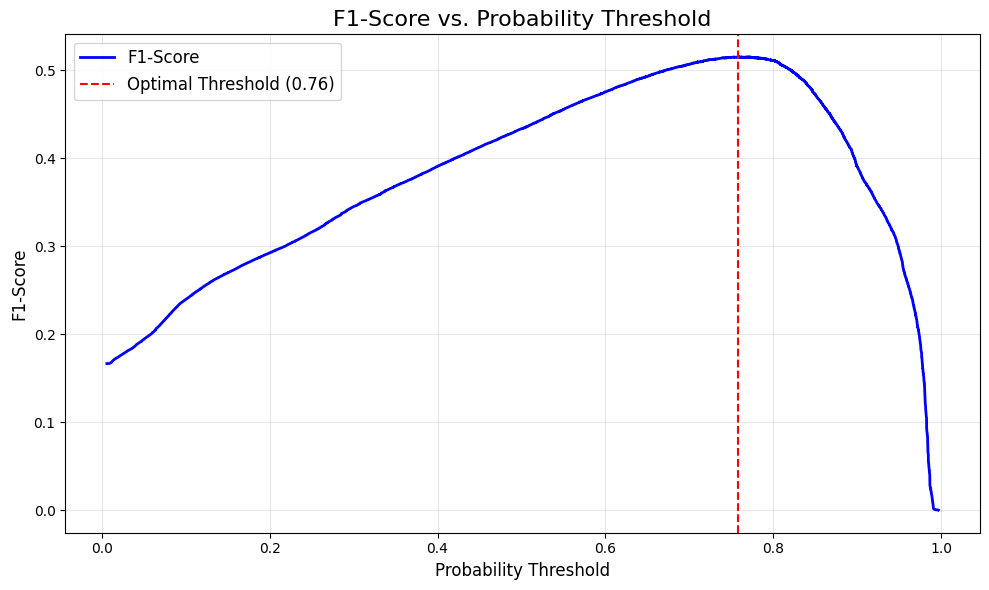

In [15]:

# 1. Get the raw probabilities for the positive class (Severe/Hospitalized)
y_probs = model_pipeline.predict_proba(X_eval)[:, 1]

# 2. Calculate Precision, Recall, and Thresholds at every possible cutoff
precision, recall, thresholds = precision_recall_curve(y_eval, y_probs)

# 3. Calculate the F1-Score for every single threshold
# (Adding a tiny number '1e-8' prevents division by zero errors)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

# 4. Find the index of the absolute highest F1-Score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precision[optimal_idx]
optimal_recall = recall[optimal_idx]

print(f"Optimal Probability Threshold: {optimal_threshold:.4f}")
print(f"Precision at Optimal: {optimal_precision:.4f}")
print(f"Recall at Optimal: {optimal_recall:.4f}")
print(f"Maximum F1-Score Achieved: {optimal_f1:.4f}")

# Apply the new custom threshold to your test set
# # "If probability >= optimal_threshold, predict 1. Else, predict 0."
y_pred_optimized = np.where(y_probs >= optimal_threshold, 1, 0)

final_model = CustomThresholdClassifier(estimator=model_pipeline, threshold=optimal_threshold)
print("\n--- New Optimized Confusion Matrix ---")
print(confusion_matrix(y_eval, y_pred_optimized))

# 5. Plot the F1-Score across all thresholds to visualize the "sweet spot"
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='blue', linewidth=2)
plt.axvline(x=optimal_threshold, color='red', linestyle='--', 
            label=f'Optimal Threshold ({optimal_threshold:.2f})')

plt.title('F1-Score vs. Probability Threshold', fontsize=16)
plt.xlabel('Probability Threshold', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8. Generate the confusion Matrix

Confusion Matrix:
[[932544  64975]
 [ 42553  57172]]


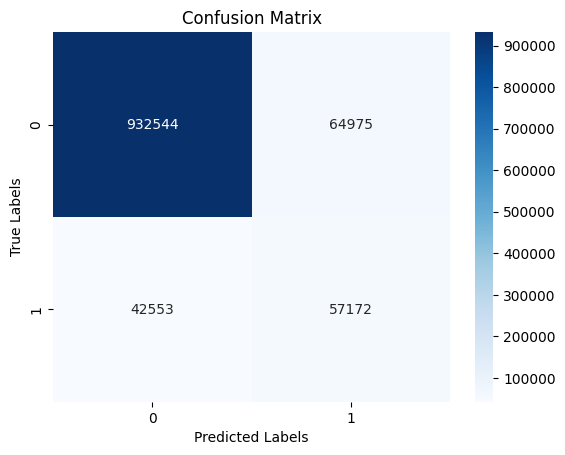

In [19]:

# Calculate the confusion matrix
cm = confusion_matrix(y_eval, y_pred_optimized)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

### 7. Generate the Precision-Recall Curve

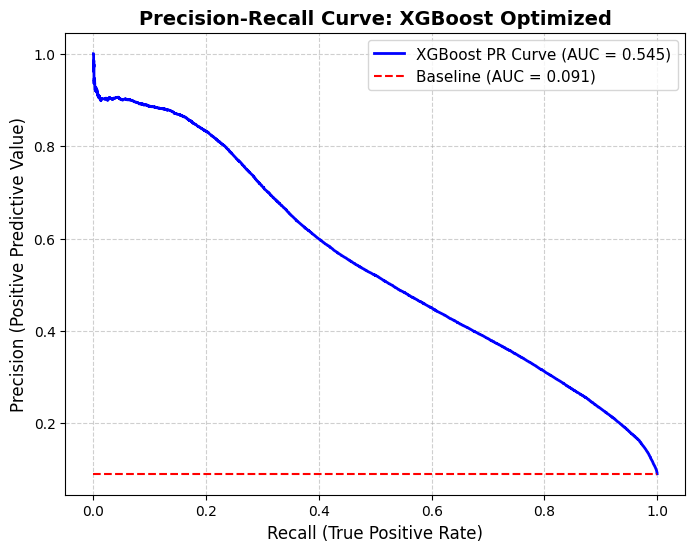

In [23]:
# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_eval, y_probs)

# Calculate the area under the PR curve
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'XGBoost PR Curve (AUC = {pr_auc:.3f})')

# 5. Plot the baseline (random guessing for PR curves = percentage of Class 1)
baseline = len(y_eval[y_eval == 1]) / len(y_eval)
plt.plot([0, 1], [baseline, baseline], color='red', linestyle='--', label=f'Baseline (AUC = {baseline:.3f})')

# 6. Formatting the chart for your CRISP-DM report
plt.title('Precision-Recall Curve: XGBoost Optimized', fontsize=14, fontweight='bold')
plt.xlabel('Recall (True Positive Rate)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Save and display
plt.savefig('xgboost_smooth_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

### 8. Plot the RUC-AUC Curve (Immaterial)

Generating Final ROC-AUC Curve for XG Boost...


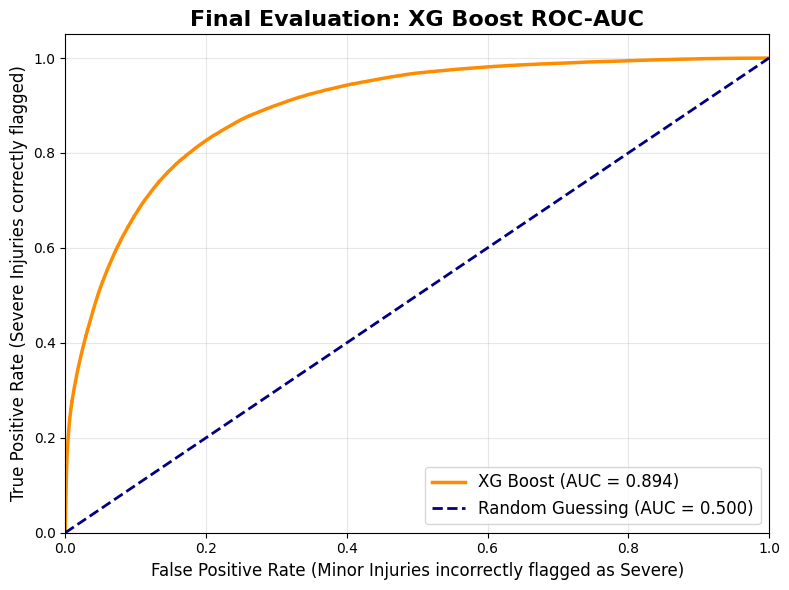

In [ ]:


def plot_single_roc(model_pipeline, X_test, y_test, model_name="Final Champion Model"):
    """
    Calculates probabilities and plots the ROC-AUC curve for a single trained model 
    against the Hold-Out Test dataset.
    """
    print(f"Generating Final ROC-AUC Curve for {model_name}...")
    
    # 1. Get the probability that the patient is in the Positive Class (Hospitalized)
    # .predict_proba() returns [Probability_Released, Probability_Hospitalized]
    # We slice [:, 1] to grab only the Hospitalized probabilities.
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]
    
    # 2. Calculate the False Positive Rate (fpr) and True Positive Rate (tpr)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    
    # 3. Calculate the Area Under the Curve (AUC) score
    roc_auc = auc(fpr, tpr)
    
    # 4. Set up the plotting canvas
    plt.figure(figsize=(8, 6))
    
    # 5. Plot the Model's Curve
    # We use a bold color (like dark orange) to make it pop for presentations
    plt.plot(fpr, tpr, color='darkorange', lw=2.5, 
             label=f'{model_name} (AUC = {roc_auc:.3f})')

    # 6. Plot the "Coin Flip" Baseline (Random Guessing)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Guessing (AUC = 0.500)')

    # 7. Format the Graph for Professional Presentation
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Minor Injuries incorrectly flagged as Severe)', fontsize=12)
    plt.ylabel('True Positive Rate (Severe Injuries correctly flagged)', fontsize=12)
    plt.title(f'Final Evaluation: {model_name} ROC-AUC', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    
    # 8. Display the Graph
    plt.tight_layout()
    plt.show()

plot_single_roc(xg_boost, X_eval, y_eval, model_name="XG Boost")

### 9. Export the model

In [ ]:
print("Exporting XGBoost pipeline to disk...")
model_path = '../models/neiss_XGboost.joblib'
joblib.dump(xg_boost, model_path)
print("Model successfully saved!")

Exporting XGBoost pipeline to disk...
Model successfully saved!


In [ ]:
n = gc.collect()
print(f"Number of unreachable objects collected: {n}")

Number of unreachable objects collected: 3221
